# ML Config — Significant Taxa, Two Platform-Matched Models (PD-vs-HC / AD-vs-HC)

**Why this notebook exists (read before running):** in `ml_02_significant_taxa.ipynb`,
the 3-class HC/PD/AD model showed a study-grouped platform-leakage AUC of 1.000
for shotgun-vs-16S using the significant-taxa feature set, plus a confusion
matrix with **zero** AD<->PD confusion despite heavy AD<->HC and PD<->HC
confusion. That combination is close to a smoking gun: because every PD
sample in this project is shotgun and every AD sample is 16S, "AD vs PD" and
"shotgun vs 16S" are the same question to a classifier - no feature
engineering or scaling fixes that, because it isn't a data-cleaning problem,
it's a study-design one (every study here is single-arm: PD+HC or AD+HC,
never PD+AD).

**The fix implemented here:** stop asking the model to separate AD from PD at
all, since that comparison is structurally unidentifiable from platform.
Instead, fit two independent binary models, each confined to a single
platform by construction:

- **Model A - PD vs HC, shotgun-only** (drops the 16S-only HC samples)
- **Model B - AD vs HC, 16S-only** (drops the shotgun-only HC samples)

Each model can no longer possibly learn "which sequencing platform is this",
because within a model every sample - case and control alike - is on the same
platform. This is a design fix, not a statistical patch: it doesn't reduce
the platform effect, it makes the platform effect a non-question.

**What this trades away:** you no longer get a single number that describes
"how separable are PD, AD, and HC together" - because that number was never
trustworthy in the first place. You get two separately-validated
disease-vs-control models, and you can *qualitatively* compare which taxa
matter for each (Step 8 below) without claiming a formal statistical
comparison between AD and PD biology - that comparison would need studies
that ran both diseases on the same platform, which don't exist in this
dataset.

**Scope note:** this same platform/disease confound is a property of *which
samples exist*, not of which feature block is used - so `ml_01`, `ml_03`,
and `ml_04` almost certainly have the identical structural issue and will
likely need the same two-model treatment before they can be trusted either.
This notebook only converts `ml_02`; treat that as a template for the other
three once the deadline pressure eases enough to redo them.

**Utils change:** `run_loso_evaluation` in `ml_pipeline_utils.py` computed the
pooled AUC with `roc_auc_score(..., multi_class="ovr", ...)`, which sklearn
rejects for a 2-class target. It now branches to a plain binary AUC when
`n_classes == 2`, and is otherwise unchanged - `ml_01`/`ml_03`/`ml_04` are
unaffected. (Also fixed an unrelated latent bug in `run_shap_analysis` that
was causing the Step 9 `AssertionError` in the original `ml_02` notebook -
it built a `get_class_values` helper to handle both old- and new-style SHAP
output shapes, but never actually called it.)

**Keep the updated `ml_pipeline_utils.py` in the same folder as this
notebook.**


In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# sys.path.append("/path/to/folder/containing/ml_pipeline_utils.py")  # uncomment and edit if needed
from ml_pipeline_utils import (
    RANDOM_STATE, run_hyperparameter_search, run_loso_evaluation_with_lasso, fit_final_lasso_selector,
    match_taxon_columns, run_loso_evaluation, plot_confusion_matrix, run_shap_analysis, save_artifacts,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

import joblib

## Step 1 - Load the master feature table and column lists

In [2]:
# ---- EDIT THESE PATHS ----
# FEATURE_TABLE_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/processed/ml_feature_table")
# OUTPUT_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/results/ml_config_sig_taxa_two_models")
FEATURE_TABLE_DIR = Path("ml_feature_table")
OUTPUT_DIR = Path("ml_config2_shared_taxa_clinical_two_models_lasso")
# ---------------------------

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

master = pd.read_csv(FEATURE_TABLE_DIR / "ml_master_feature_table.csv", index_col=0)

def load_list(path):
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]

all_taxa_columns         = load_list(FEATURE_TABLE_DIR / "all_taxa_columns.txt")
significant_taxa_columns = load_list(FEATURE_TABLE_DIR / "significant_taxa_columns.txt")
clinical_columns         = load_list(FEATURE_TABLE_DIR / "clinical_columns.txt")
pathway_columns          = load_list(FEATURE_TABLE_DIR / "pathway_columns.txt")

print("Master table:", master.shape)
print(master["disease_group"].value_counts())
print(master.groupby(["disease_group", "platform"]).size())

Master table: (1822, 752)
disease_group
HC    755
PD    751
AD    316
Name: count, dtype: int64
disease_group  platform
AD             16S         316
HC             16S         294
               shotgun     461
PD             shotgun     751
dtype: int64


## Step 2 - Confirm the master table is what you expect

In [3]:
assert master[all_taxa_columns].isna().sum().sum() == 0, "Unexpected NaNs in taxa columns"
assert master[clinical_columns].isna().sum().sum() == 0, "Unexpected NaNs in clinical columns"
assert master[pathway_columns].isna().sum().sum() == 0, "Unexpected NaNs in pathway columns"
print("No unexpected NaNs found in the feature blocks - good to proceed.")

No unexpected NaNs found in the feature blocks - good to proceed.


## Step 3 - Select this notebook's feature set

Same as `ml_02`: the ANCOM-BC2-significant genera union (PD-specific +
AD-specific + shared). We keep this shared feature set for both models below
so the comparison in Step 8 is apples-to-apples; if `ml_00` later exports
disease-specific significant-taxa lists, each model could instead use only
its own disease's significant genera - a worthwhile refinement, not done here
to keep this change minimal ahead of the deadline.

In [4]:
feature_cols = significant_taxa_columns
print(f"Using {len(feature_cols)} significant-taxa features.")

Using 43 significant-taxa features.


In [5]:
# ---- EDIT THIS: local copies of the ANCOM-BC2 disease-specific outputs ----
PD_SPECIFIC_CSV = Path("pd_specific_genera.csv")
AD_SPECIFIC_CSV = Path("ad_specific_genera.csv")
# -----------------------------------------------------------------------

shared_taxa = ["g__Enterococcus", "g__Roseburia", "g__Haemophilus", "g__Clostridium",
               "g__Faecalibacterium", "g__Eisenbergiella", "g__Lachnospira"]

pd_specific_taxa = pd.read_csv(PD_SPECIFIC_CSV)["taxon"].tolist()
ad_specific_taxa = pd.read_csv(AD_SPECIFIC_CSV)["taxon"].tolist()

shared_cols      = match_taxon_columns(shared_taxa, all_taxa_columns, label="shared taxa")
pd_specific_cols = match_taxon_columns(pd_specific_taxa, all_taxa_columns, label="PD-specific taxa")
ad_specific_cols = match_taxon_columns(ad_specific_taxa, all_taxa_columns, label="AD-specific taxa")

# Each model gets its own disease's significant taxa + shared taxa + clinical
# - not the shared-only intersection used previously.
pd_feature_cols = sorted(set(shared_cols) | set(pd_specific_cols)) + clinical_columns
ad_feature_cols = sorted(set(shared_cols) | set(ad_specific_cols)) + clinical_columns

print(f"Model A (PD vs HC) features: {len(pd_feature_cols)} "
      f"({len(pd_specific_cols)} PD-specific + {len(shared_cols)} shared + {len(clinical_columns)} clinical)")
print(f"Model B (AD vs HC) features: {len(ad_feature_cols)} "
      f"({len(ad_specific_cols)} AD-specific + {len(shared_cols)} shared + {len(clinical_columns)} clinical)")


Model A (PD vs HC) features: 44 (31 PD-specific + 7 shared + 6 clinical)
Model B (AD vs HC) features: 25 (12 AD-specific + 7 shared + 6 clinical)


## Step 4 - Split into two platform-matched subsets (replaces the platform-leakage diagnostic)

This is the actual fix. Each subset below is restricted to a single
platform, so within either model there is no shotgun/16S axis left for the
classifier to find - "which platform" and "which class" are no longer
confounded because platform is now constant within each model.

- **Model A (shotgun-only): PD vs HC** - drops the 16S-only HC samples.
- **Model B (16S-only): AD vs HC** - drops the shotgun-only HC samples.

The assertions below aren't decorative - they're the thing that actually
proves the fix worked: `platform.nunique() == 1` in each subset means the
confound is gone by construction, not by hope.

In [6]:
pd_df = master[(master["disease_group"].isin(["PD","HC",])) & (master["platform"] == "shotgun")].reset_index(drop=True)
ad_df = master[(master["disease_group"].isin(["AD","HC",])) & (master["platform"] == "16S")].reset_index(drop=True)

assert (pd_df["platform"].nunique()== 1)
assert (ad_df["platform"].nunique()== 1)

print("\n Model A - PD vs HC (shotgun-only)")
print(pd_df["disease_group"].value_counts())
print("\n ModeL B - AD vs HC (16S-only)")
print(ad_df["disease_group"].value_counts())

# Sanity check: confirm we haven't silently dropped every HC sample from
# either subset (would happen if the platform column values don't match
# "shotgun"/"16S" exactly - fail loudly instead of training on an empty class)
assert pd_df["disease_group"].value_counts().min() > 0, "One class is empty in the PD/HC subset - check platform label spelling"
assert ad_df["disease_group"].value_counts().min() > 0, "One class is empty in the AD/HC subset - check platform label spelling"


 Model A - PD vs HC (shotgun-only)
disease_group
PD    751
HC    461
Name: count, dtype: int64

 ModeL B - AD vs HC (16S-only)
disease_group
AD    316
HC    294
Name: count, dtype: int64


## Step 5 - One function, run twice

Steps 5-10 of the original `ml_02` (encode labels, scale, tune, LOSO-evaluate,
confusion matrix, SHAP, save artifacts) are identical in shape for both
models - only the input subset and an output subfolder differ. Wrapping that
in one function keeps the two runs from drifting apart the way copy-pasted
notebook cells tend to.

`n_splits` for the inner hyperparameter search is capped at the smaller
class's study count (never below 2), since `StratifiedGroupKFold` needs at
least that many groups per class - the same guard `check_platform_leakage`
already uses elsewhere in this pipeline.

In [7]:
def run_one_model(df,feature_cols,model_label,output_subdir,):
    print(f"\n{'='*70}\n"
          f"Running model: "
          f"{model_label}\n"
          f"{'='*70}"
          )
    sub_output_dir = (
        OUTPUT_DIR /
        output_subdir
    )

    sub_output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # ======================================================
    # LABEL ENCODING
    # ======================================================
    label_encoder = LabelEncoder()
    df = df.copy()
    df["y"] = label_encoder.fit_transform(df["disease_group"])
    print("Class encoding:",dict(zip(label_encoder.classes_,label_encoder.transform(label_encoder.classes_))))

    X = df[feature_cols].values
    y = df["y"].values
    groups = df["study_id"].values

    print(f"Initial feature count: {len(feature_cols)}")

    # ======================================================
    # INNER CV SPLITS
    # ======================================================
    n_studies_per_class = (df.groupby("disease_group")["study_id"].nunique())
    n_splits = max(2,min(5,int(n_studies_per_class.min())))

    # ======================================================
    # RF HYPERPARAMETER SEARCH
    # ======================================================
    grid = run_hyperparameter_search(X,y,groups,n_splits=n_splits,)

    # ======================================================
    # LOSO + LASSO
    # ======================================================
    (
        loso_df,
        all_y_true,
        all_y_pred,
        all_y_proba,
    ) = run_loso_evaluation_with_lasso(
        X=X,
        y=y,
        groups=groups,
        feature_cols=feature_cols,
        best_params=grid.best_params_,
        label_encoder=label_encoder,
        output_dir=sub_output_dir,
        min_features=1,
    )

    # ======================================================
    # CONFUSION MATRIX
    # ======================================================
    cm_df = plot_confusion_matrix(all_y_true,all_y_pred,label_encoder,sub_output_dir,)

    # ======================================================
    # STUDY-LEVEL METRICS
    # ======================================================
    print("\nStudy-level LOSO metrics:")
    display(loso_df.sort_values("f1_macro"))

    # ======================================================
    # FINAL LASSO
    # ======================================================
    (
        final_selected_indices,
        final_selected_features,
        final_lasso_scaler,
        final_lasso_model,
    ) = fit_final_lasso_selector(
        X=X,
        y=y,
        feature_cols=feature_cols,
        min_features=1,
    )

    # ======================================================
    # FINAL RF
    # ======================================================
    X_final = X[:,final_selected_indices]
    final_model = RandomForestClassifier(**grid.best_params_,class_weight="balanced",random_state=RANDOM_STATE,n_jobs=-1,)
    final_model.fit(X_final,y,)

    # ======================================================
    # SHAP
    # ======================================================
    shap_values = run_shap_analysis(final_model,X_final,final_selected_features,label_encoder,sub_output_dir,max_display=30,)

    # ======================================================
    # SAVE
    # ======================================================
    save_artifacts(final_model,None,label_encoder,final_selected_features,sub_output_dir,)

    joblib.dump(final_lasso_scaler,sub_output_dir / "lasso_scaler.joblib",)
    joblib.dump(final_lasso_model,sub_output_dir / "lasso_selector.joblib",)
    return {"model_label":model_label,
            "label_encoder":label_encoder,
            "final_model":final_model,
            "final_selected_features":final_selected_features,
            "grid":grid,
            "loso_df":loso_df,
            "cm_df":cm_df,
            "shap_values":shap_values,
            }

## Step 6 - Model A: PD vs HC (shotgun-only)


Running model: PD vs HC (shotgun-only, PD-specific+shared taxa + clinical)
Class encoding: {'HC': np.int64(0), 'PD': np.int64(1)}
Initial feature count: 44
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV f1_macro: 0.6316098374720605

Fold 0 (held out bedarf2017)
LASSO selected 23/44 features
n=59, classes_present=2/2, Accuracy=0.508, F1_macro=0.469, AUC=0.646

Fold 1 (held out boktor2023_rumc)
LASSO selected 39/44 features
n=113, classes_present=2/2, Accuracy=0.717, F1_macro=0.709, AUC=0.798

Fold 2 (held out boktor2023_tbc)
LASSO selected 44/44 features
n=112, classes_present=2/2, Accuracy=0.679, F1_macro=0.676, AUC=0.889

Fold 3 (held out clasen2024)
LASSO selected 36/44 features
n=126, classes_present=2/2, Accuracy=0.833, F1_macro=0.534, AUC=0.826

Fold 4 (held out mao2021)
LASSO selected 24/44 features
n=78, classes_present=2/2, Accuracy=0.628, F1_macro=0.593, AUC=0.751

Fold 5 (hel

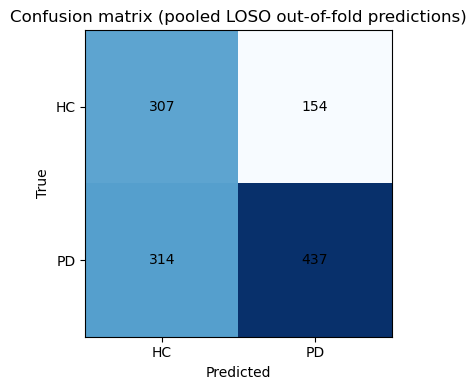

              precision    recall  f1-score   support

          HC       0.49      0.67      0.57       461
          PD       0.74      0.58      0.65       751

    accuracy                           0.61      1212
   macro avg       0.62      0.62      0.61      1212
weighted avg       0.65      0.61      0.62      1212


Study-level LOSO metrics:


,held_out_study,n_test_samples,n_classes_present,n_selected_features,selected_features,accuracy,f1_macro,auc,actual_HC,actual_PD,predicted_HC,predicted_PD
0,bedarf2017,59,2,23,taxon__g__Anaerotruncus;taxon__g__Candidatus_W...,0.508475,0.469457,0.646313,28,31,47,12
3,clasen2024,126,2,36,taxon__g__Anaerostipes;taxon__g__Anaerotruncus...,0.833333,0.533744,0.825612,22,104,3,123
5,wallen2022,724,2,41,taxon__g__Anaerotruncus;taxon__g__Blautia;taxo...,0.556630,0.555815,0.673016,234,490,459,265
4,mao2021,78,2,24,taxon__g__Anaerotruncus;taxon__g__Candidatus_W...,0.628205,0.592799,0.751479,39,39,16,62
2,boktor2023_tbc,112,2,44,taxon__g__Anaerostipes;taxon__g__Anaerotruncus...,0.678571,0.675988,0.888889,67,45,35,77
1,boktor2023_rumc,113,2,39,taxon__g__Anaerostipes;taxon__g__Anaerotruncus...,0.716814,0.708575,0.798122,71,42,61,52



Final full-data LASSO selection:
39 / 44 features retained
Generating SHAP beeswarm for class: HC


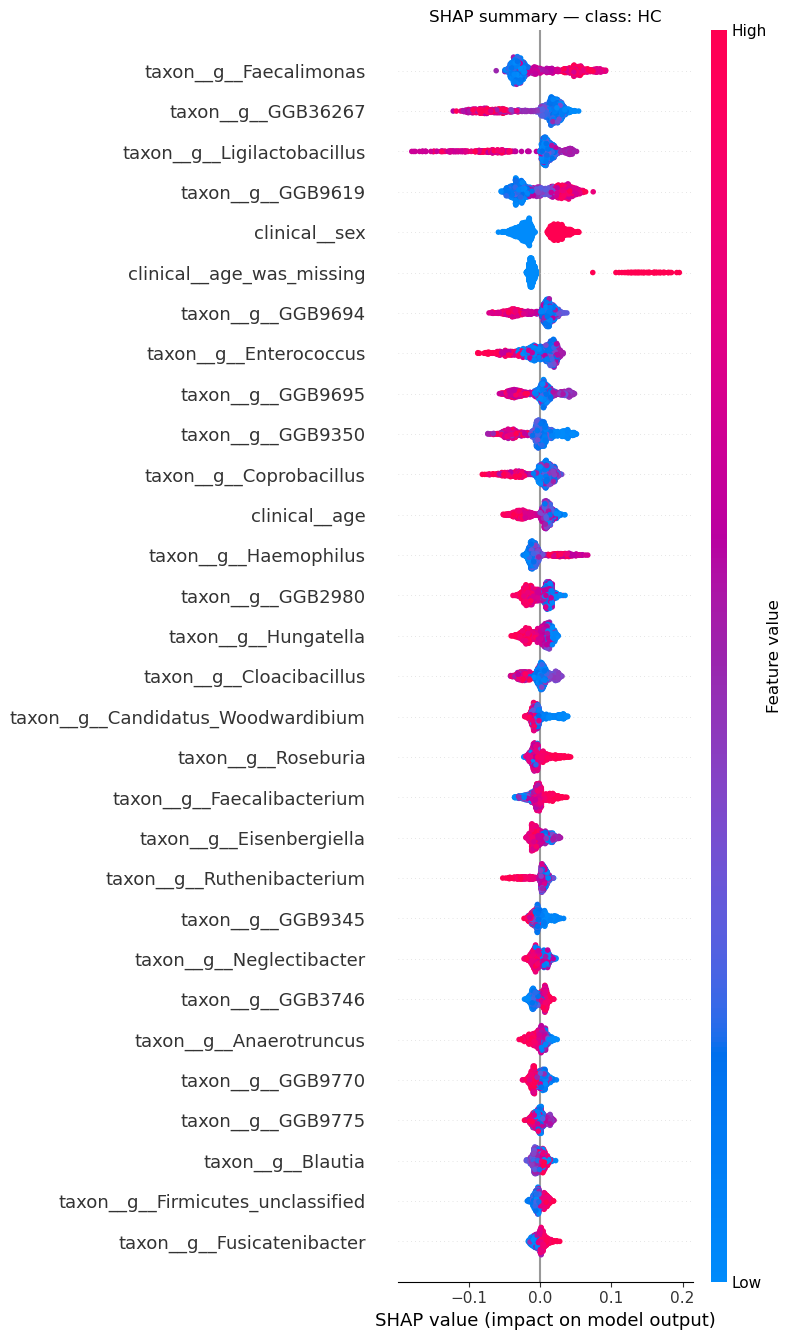

Generating SHAP beeswarm for class: PD


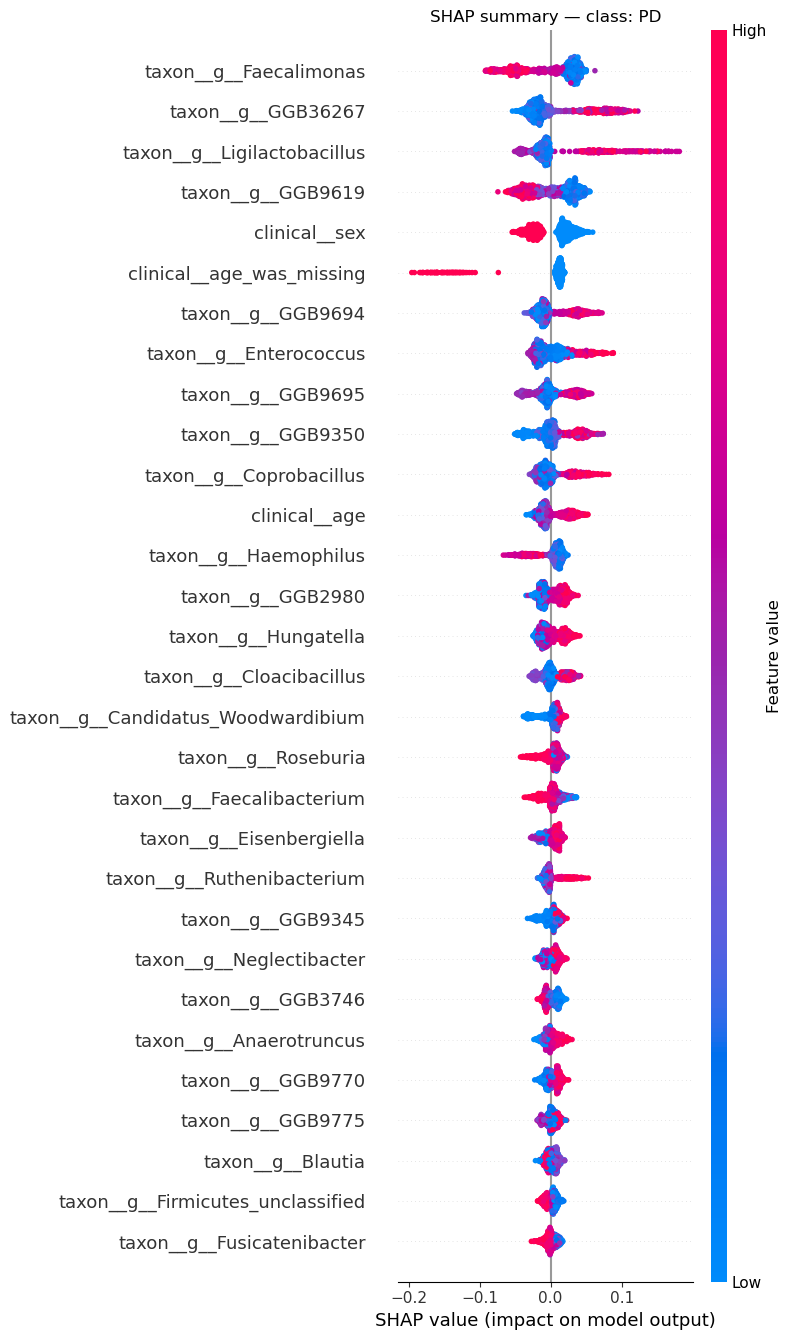

Saved model, scaler, label encoder, and feature list to: ml_config2_shared_taxa_clinical_two_models_lasso\pd_vs_hc_shotgun


<Figure size 640x480 with 0 Axes>

In [8]:
pd_results = run_one_model(pd_df, pd_feature_cols, "PD vs HC (shotgun-only, PD-specific+shared taxa + clinical)", "pd_vs_hc_shotgun",)


## Step 7 - Model B: AD vs HC (16S-only)


Running model: AD vs HC (16S-only, AD-specific+shared taxa + clinical)
Class encoding: {'AD': np.int64(0), 'HC': np.int64(1)}
Initial feature count: 25
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV f1_macro: 0.5957026208470404

Fold 0 (held out binyinli2019)
LASSO selected 6/25 features
n=60, classes_present=2/2, Accuracy=0.567, F1_macro=0.562, AUC=0.586

Fold 1 (held out cirstea2022)
LASSO selected 3/25 features
n=98, classes_present=2/2, Accuracy=0.643, F1_macro=0.643, AUC=0.646

Fold 2 (held out ling2021)
LASSO selected 23/25 features
n=171, classes_present=2/2, Accuracy=0.626, F1_macro=0.517, AUC=0.598

Fold 3 (held out liu2019)
LASSO selected 24/25 features
n=61, classes_present=2/2, Accuracy=0.557, F1_macro=0.540, AUC=0.595

Fold 4 (held out yamashiro2024)
LASSO selected 5/25 features
n=37, classes_present=2/2, Accuracy=0.568, F1_macro=0.560, AUC=0.630

Fold 5 (held out yildirim

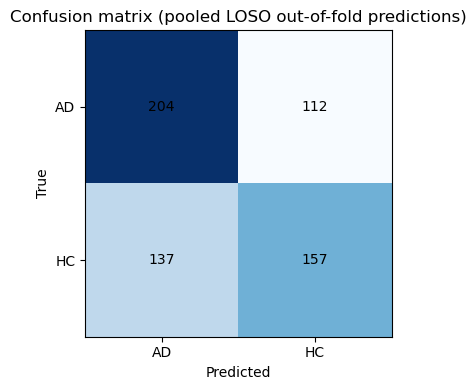

              precision    recall  f1-score   support

          AD       0.60      0.65      0.62       316
          HC       0.58      0.53      0.56       294

    accuracy                           0.59       610
   macro avg       0.59      0.59      0.59       610
weighted avg       0.59      0.59      0.59       610


Study-level LOSO metrics:


,held_out_study,n_test_samples,n_classes_present,n_selected_features,selected_features,accuracy,f1_macro,auc,actual_AD,actual_HC,predicted_AD,predicted_HC
2,ling2021,171,2,23,taxon__g__Agathobacter;taxon__g__Agathobaculum...,0.625731,0.517460,0.598451,100,71,152,19
5,yildirim2022,97,2,6,taxon__g__Agathobaculum;taxon__g__Bifidobacter...,0.546392,0.538095,0.548936,47,50,37,60
3,liu2019,61,2,24,taxon__g__Agathobacter;taxon__g__Agathobaculum...,0.557377,0.539558,0.595238,33,28,16,45
4,yamashiro2024,37,2,5,taxon__g__Agathobaculum;taxon__g__Haemophilus;...,0.567568,0.559524,0.630117,18,19,24,13
0,binyinli2019,60,2,6,taxon__g__Agathobaculum;taxon__g__Haemophilus;...,0.566667,0.562290,0.585556,30,30,24,36
6,zhuang2018,86,2,6,taxon__g__Agathobaculum;taxon__g__Haemophilus;...,0.569767,0.568308,0.554083,43,43,38,48
1,cirstea2022,98,2,3,taxon__g__Agathobaculum;taxon__g__Lachnospira;...,0.642857,0.642522,0.646122,45,53,50,48



Final full-data LASSO selection:
6 / 25 features retained
Generating SHAP beeswarm for class: AD


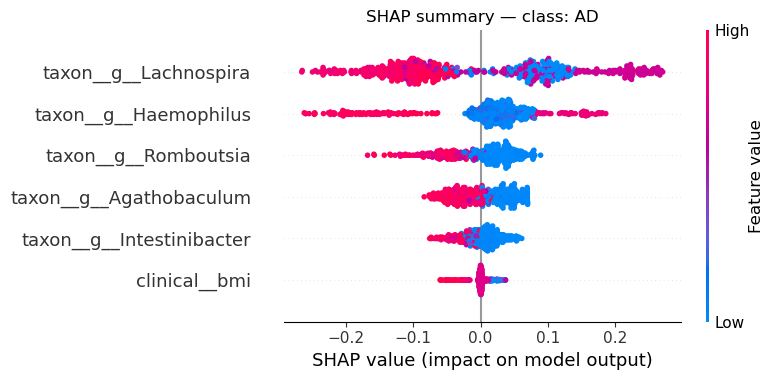

Generating SHAP beeswarm for class: HC


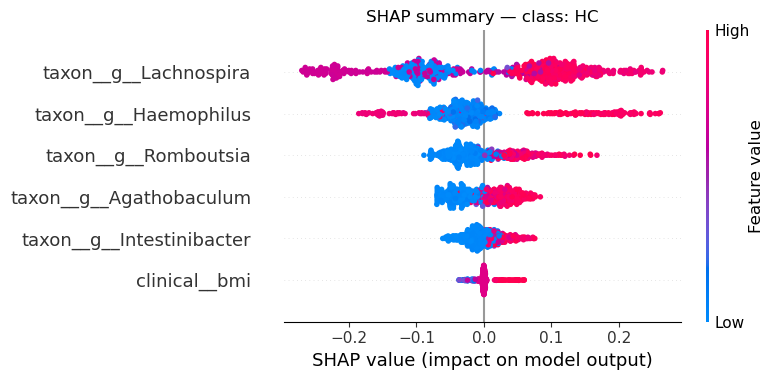

Saved model, scaler, label encoder, and feature list to: ml_config2_shared_taxa_clinical_two_models_lasso\ad_vs_hc_16s


<Figure size 640x480 with 0 Axes>

In [9]:
ad_results = run_one_model(ad_df, ad_feature_cols, "AD vs HC (16S-only, AD-specific+shared taxa + clinical)", "ad_vs_hc_16s",)


## Step 8 - Compare the two models' top taxa (qualitative, not a statistical test)

This is *not* a formal AD-vs-PD comparison - that comparison would need
studies running both diseases on the same platform, which don't exist here.
What this table gives you is a side-by-side of which significant genera each
disease-vs-HC model actually leaned on (Gini importance from each model's
final RF, plus which model each genus ranks higher in). Useful for a
"shared vs distinct candidate taxa" discussion in the thesis, framed
explicitly as suggestive rather than confirmatory given the platforms
differ.

In [10]:
pd_importances = pd.Series(pd_results["final_model"].feature_importances_,
                           index=pd_results["final_selected_features"], name="importance_PD_vs_HC")
ad_importances = pd.Series(ad_results["final_model"].feature_importances_,
                           index=ad_results["final_selected_features"], name="importance_AD_vs_HC")

comparison_df = pd.concat([pd_importances, ad_importances], axis=1)

comparison_df["in_model"] = np.select(
    [comparison_df["importance_PD_vs_HC"].notna() & comparison_df["importance_AD_vs_HC"].notna(),
     comparison_df["importance_PD_vs_HC"].notna()],
    ["both (post-LASSO)", "PD_vs_HC only"],
    default="AD_vs_HC only"
)

comparison_df["rank_PD_vs_HC"] = comparison_df["importance_PD_vs_HC"].rank(ascending=False)
comparison_df["rank_AD_vs_HC"] = comparison_df["importance_AD_vs_HC"].rank(ascending=False)

# Only meaningful for rows present in BOTH models' final LASSO-selected sets -
# NaN vs a rank always compares False in numpy, so the old np.where() version
# silently mislabelled every single-model row as "AD_vs_HC". Leave those blank.
comparison_df["higher_ranked_in"] = np.nan
both_mask = comparison_df["in_model"] == "both (post-LASSO)"
comparison_df.loc[both_mask, "higher_ranked_in"] = np.where(
    comparison_df.loc[both_mask, "rank_PD_vs_HC"] < comparison_df.loc[both_mask, "rank_AD_vs_HC"],
    "PD_vs_HC", "AD_vs_HC"
)

comparison_df = comparison_df.sort_values(
    ["importance_PD_vs_HC", "importance_AD_vs_HC"], ascending=False, na_position="last"
)

comparison_df.to_csv(OUTPUT_DIR / "feature_importance_comparison.csv")
comparison_df.head(20)


C:\Users\Aishwarya\AppData\Local\Temp\ipykernel_52420\1024724687.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['AD_vs_HC' 'AD_vs_HC' 'AD_vs_HC']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comparison_df.loc[both_mask, "higher_ranked_in"] = np.where(


,importance_PD_vs_HC,importance_AD_vs_HC,in_model,rank_PD_vs_HC,rank_AD_vs_HC,higher_ranked_in
taxon__g__GGB36267,0.063549,NaN,PD_vs_HC only,1.0,NaN,NaN
taxon__g__Ligilactobacillus,0.062038,NaN,PD_vs_HC only,2.0,NaN,NaN
taxon__g__Faecalimonas,0.052594,NaN,PD_vs_HC only,3.0,NaN,NaN
taxon__g__Enterococcus,0.044488,NaN,PD_vs_HC only,4.0,NaN,NaN
taxon__g__GGB9619,0.044034,NaN,PD_vs_HC only,5.0,NaN,NaN
taxon__g__GGB9695,0.041840,NaN,PD_vs_HC only,6.0,NaN,NaN
taxon__g__GGB9694,0.040255,NaN,PD_vs_HC only,7.0,NaN,NaN
clinical__age_was_missing,0.040030,NaN,PD_vs_HC only,8.0,NaN,NaN
taxon__g__Coprobacillus,0.038889,NaN,PD_vs_HC only,9.0,NaN,NaN
taxon__g__GGB9350,0.038478,NaN,PD_vs_HC only,10.0,NaN,NaN


## Notes for the Methods/limitations section

- The original `ml_02` 3-class HC/PD/AD model is superseded by these two
  binary models for reporting purposes: its AD-vs-PD boundary was shown to be
  structurally confounded with sequencing platform (study-grouped platform
  AUC of 1.000; zero AD<->PD confusion, heavy AD/PD<->HC confusion), and no
  feature or scaling choice can separate platform from disease group on that
  axis because every PD study is shotgun and every AD study is 16S.
- Each model here (PD vs HC shotgun-only; AD vs HC 16S-only) is single-platform
  by construction, so it cannot learn platform as a proxy for the label - the
  `platform.nunique() == 1` assertions in Step 4 are the evidence for this,
  not just a comment.
- The Step 8 feature-importance comparison is descriptive only. Do not
  present it as a statistical AD-vs-PD contrast - frame any shared-taxa
  observations as hypothesis-generating, since a platform confound between
  the two disease groups still exists at the *comparison* level even though
  it no longer exists *within* either individual model.
- Consider applying this same platform-matched two-model split to `ml_01`
  (all taxa), `ml_03` (+clinical), and `ml_04` (+pathway) if time allows -
  they share the identical sample-level confound regardless of feature block.